In [1]:
#1
from scipy.stats import bernoulli, binom
from matplotlib.pyplot import bar, show, hist, grid, legend, xticks

In [4]:
#a
def deplasare(n,p):
    pozitii=[0]
    poz=0
    deplasari=bernoulli.rvs(p,size=n)
    for pas in deplasari:
        pas=int(pas)
        poz+=2*pas-1
        pozitii.append(poz)
    return pozitii

In [7]:
print(deplasare(50,0.9))

[0, 1, 2, 3, 2, 3, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 40, 41, 42]


In [10]:
#b
def simulare_multipla(k, n, p):
    finale = []
    for _ in range(k):
        pozitii = deplasare(n, p)
        finale.append(pozitii[-1])

    bin_edges=[ k + 0.5 for k in range(-n-1,n+1) ]
    hist(finale,bins=bin_edges , density = True, rwidth = 0.9, color = 'green', edgecolor = 'black',
        alpha = 0.5, label = 'frecvente relative')
    
    distribution = dict([(2*k-n,binom.pmf(k,n,p)) for k in range (0,n)])
    bar(list(distribution.keys()),list(distribution.values()), width = 0.6, color = 'red', edgecolor = 'black',
        alpha= 0.6, label = 'probabilitati')

    legend(loc = 'lower left')
    grid()
    show()

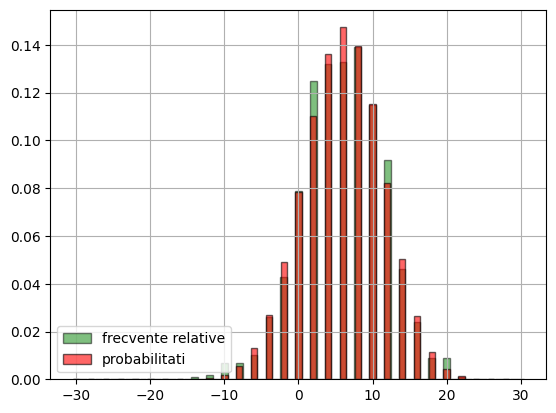

In [53]:
simulare_multipla(1000, 30, 0.6)


In [14]:
#
def deplasare_cerc(pasii, p, n):
    pozitii = [0]
    poz = 0
    deplasari = bernoulli.rvs(p, size=pasii)
    for pas in deplasari:
        pas=int(pas)
        poz = (poz + (2*pas - 1)) % n
        pozitii.append(poz)
    return pozitii

def simulare_multipla_cerc(k, pasii, p, n):
    finale = []
    for _ in range(k):
        pozitii = deplasare_cerc(pasii, p, n)
        finale.append(pozitii[-1])
    
    counts = [finale.count(i) for i in range(n)]
    bin_edges=[ k + 0.5 for k in range(0,n+1) ]
    hist(finale,bins=bin_edges , density = True, rwidth = 0.9, color = 'green', edgecolor = 'black',
        alpha = 0.5, label = 'frecvente relative')
    
    distribution = dict([(k,binom.pmf(k,n,p)) for k in range (0,n)])
    bar(list(distribution.keys()),list(distribution.values()), width = 0.85, color = 'red', edgecolor = 'black',
        alpha= 0.6, label = 'probabilitati')

    legend(loc = 'lower left')
    grid()
    show()

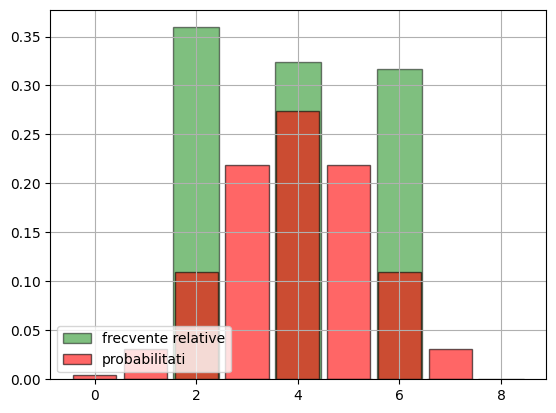

In [15]:
simulare_multipla_cerc(1000, 30, 0.5, 8)

In [17]:
from scipy.stats import hypergeom, geom
import numpy as np

n=49
n1=6
n2=6

def simulare(size):
    prob_castig=sum([hypergeom.pmf(k,n,n1,n2) for k in range(3,7)])

    bilete_necastigatoare=geom.rvs(prob_castig,size=size)-1

    return bilete_necastigatoare

In [19]:
rez = simulare(1)
print(rez)

[60]


In [48]:
def cerinta_ii(num_simulari):
    p = sum(hypergeom.pmf(k, 49, 6, 6) for k in range(3, 7))

    prob_teoretica = (1 - p)**10

    mostre = simulare(num_simulari)
    prob_simulare = np.mean(mostre >= 10)

    return prob_teoretica, prob_simulare

In [49]:
pt, ps = cerinta_ii(10000)
print("Teoretica", pt)
print("Simulare:", ps)

Teoretica 0.82850357564066
Simulare: 0.83


TypeError: unsupported operand type(s) for -: 'list' and 'int'